> (중요) 여러분 구글 드라이브에 최소 7GB 이상은 확보되어 있어야 합니다!

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> (주의) 아래 코드는 처음 딱 한 번만!

In [3]:
# import zipfile
# import os
# import shutil
# import time

# # 1. 경로 설정
# dataset_zip = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/초급_프로젝트_수강생_배포용.zip")
# extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")

# os.makedirs(extract_path, exist_ok=True)

# # 2. 메인 압축파일 해제
# print(f"📦 메인 데이터셋 해제 중: {os.path.basename(dataset_zip)}")
# with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# # 메인 압축파일 삭제 (요청사항)
# os.remove(dataset_zip)
# print("🗑️ 메인 압축파일 삭제 완료.")

# # 3. 내부 이미지 압축파일 통합 해제 로직
# print("\n🚀 이미지 폴더 통합 및 내부 압축 해제 시작...")
# for file in os.listdir(extract_path):
#     if file.endswith(".zip"):
#         file_path = os.path.join(, file)
        
#         # 이름 기반 대상 폴더 결정 (train/test 통합)
#         if 'train' in file.lower():
#             target_folder_name = "train_images"
#         elif 'test' in file.lower():
#             target_folder_name = "test_images"
#         else:
#             target_folder_name = file.replace(".zip", "")

#         target_subfolder = os.path.join(extract_path, target_folder_name)
#         os.makedirs(target_subfolder, exist_ok=True)

#         print(f"📂 {file} -> {target_folder_name} 통합 중...")
        
#         with zipfile.ZipFile(file_path, 'r') as zip_ref:
#             for member in zip_ref.infolist():
#                 if not member.is_dir():
#                     # 내부 경로 구조를 무시하고 파일명만 추출하여 저장
#                     filename = os.path.basename(member.filename)
#                     if filename:
#                         target_file_path = os.path.join(target_subfolder, filename)
#                         with zip_ref.open(member) as source, open(target_file_path, "wb") as target:
#                             shutil.copyfileobj(source, target)
        
#         # [수정 포인트] 삭제 전 잠시 대기 후 강제 삭제 시도
#         try:
#             time.sleep(0.5) 
#             if os.path.exists(file_path):
#                 os.remove(file_path)
#                 print(f"🗑️ 삭제 성공: {file}")
#         except Exception as e:
#             print(f"❌ {file} 삭제 실패: {e}")

# print("\n✨ 모든 작업이 완료되었습니다!")
# print(f"📁 최종 데이터셋 구성: {os.listdir(extract_path)}")

- 구글 드라이브 휴지통 비우기

In [4]:
# from google.colab import auth
# from googleapiclient.discovery import build

# # 1. 구글 드라이브 인증
# auth.authenticate_user()
# drive_service = build('drive', 'v3')

# # 2. 휴지통 완전히 비우기 함수
# def empty_trash():
#     try:
#         drive_service.files().emptyTrash().execute()
#         print("✅ 구글 드라이브 휴지통이 완전히 비워졌습니다.")
#     except Exception as e:
#         print(f"❌ 휴지통 비우기 실패: {e}")

# # 실행
# empty_trash()

> 압축 해제한 파일들의 반영 시간이 걸릴 수 있으므로, 커널 재시작 해주기!

#### `normalize_path`는?

`normalize_path`는 파일 경로에 포함된 **한글(유니코드) 처리 방식**을 통일하여, 경로를 찾지 못하는 에러를 방지하기 위한 함수입니다.

특히 **Google Colab**이나 **Mac, Windows** 사이에서 데이터를 주고받을 때 한글 폴더명이 깨져서 발생하는 `File Not Found` 에러를 잡는 데 필수적입니다.

<br>

##### 왜 사용하나요? (NFC vs NFD)

한글을 컴퓨터가 인식하는 방식은 크게 두 가지입니다.

* **NFC (Windows 스타일):** '강'을 '강'이라는 하나의 글자로 저장합니다.
* **NFD (Mac/Unix 스타일):** '강'을 'ㄱ', 'ㅏ', 'ㅇ'으로 쪼개서 저장합니다.

사람 눈에는 똑같이 "초급 프로젝트"라고 보이지만, 컴퓨터 입장에서는 글자 조합 방식이 다르면 **완전히 다른 경로**로 인식합니다. `normalize_path` 는 이를 **NFC(표준 방식)** 로 강제 통일해주는 역할을 합니다.

In [2]:
############################################################
# 0. 라이브러리 임포트 & 경로 설정
############################################################
import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()


**yolo용 폴더 구조로 변환**

> 기존 이미지와 라벨들을 아래 구조처럼 맞춰줌.

```bash
/content/dataset/
  ├── train/
  │    ├── images/  #<-- 여기에 .jpg 파일들 이동
  │    └── labels/  #<-- 여기에 .txt 파일들 생성
  └── val/
       ├── images/  #<-- 여기에 .jpg 파일들 이동
       └── labels/  #<-- 여기에 .txt 파일들 생성
```

> 한 번만 실행하기

In [6]:
"""
import os
import shutil

base_path = "/content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn"
yolo_path = "/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo"

def reorganize_yolo(mode):
    # 기존 폴더명 (예: train_images, test_images)
    old_img_dir = os.path.join(base_path, f'{mode}_images')
    
    # 새로운 표준 구조 (예: train/images, train/labels)
    new_mode = 'train' if mode == 'train' else 'val'
    new_root = os.path.join(yolo_path, new_mode)
    new_img_dir = os.path.join(new_root, 'images')
    new_lbl_dir = os.path.join(new_root, 'labels')
    
    os.makedirs(new_img_dir, exist_ok=True)
    os.makedirs(new_lbl_dir, exist_ok=True)
    
    # 이미지 파일 이동
    for f in os.listdir(old_img_dir):
        shutil.move(os.path.join(old_img_dir, f), os.path.join(new_img_dir, f))

# 실행
reorganize_yolo('train')
reorganize_yolo('test') # test를 val 용도로 변경
"""

'\nimport os\nimport shutil\n\nbase_path = "/content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn"\nyolo_path = "/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo"\n\ndef reorganize_yolo(mode):\n    # 기존 폴더명 (예: train_images, test_images)\n    old_img_dir = os.path.join(base_path, f\'{mode}_images\')\n    \n    # 새로운 표준 구조 (예: train/images, train/labels)\n    new_mode = \'train\' if mode == \'train\' else \'val\'\n    new_root = os.path.join(yolo_path, new_mode)\n    new_img_dir = os.path.join(new_root, \'images\')\n    new_lbl_dir = os.path.join(new_root, \'labels\')\n    \n    os.makedirs(new_img_dir, exist_ok=True)\n    os.makedirs(new_lbl_dir, exist_ok=True)\n    \n    # 이미지 파일 이동\n    for f in os.listdir(old_img_dir):\n        shutil.move(os.path.join(old_img_dir, f), os.path.join(new_img_dir, f))\n\n# 실행\nreorganize_yolo(\'train\')\nreorganize_yolo(\'test\') # test를 val 용도로 변경\n'

In [7]:
"""
# 경로는 환경에 맞게 수정
# train_images, test_images
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn") # 압축을 풀 폴더

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train", "images")
TEST_IMG_DIR  = os.path.join(extract_path, "val", "images")

# merged_annotation json 경로
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
"""

'\n# 경로는 환경에 맞게 수정\n# train_images, test_images\nextract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn") # 압축을 풀 폴더\n\nTRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")\nTEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")\nTRAIN_IMG_DIR = os.path.join(extract_path, "train", "images")\nTEST_IMG_DIR  = os.path.join(extract_path, "val", "images")\n\n# merged_annotation json 경로\nDEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n'

In [3]:
import os
import torch

# 📌 1. 기본 경로 설정 (normalize_path 함수가 정의되어 있어야 합니다)
# 원본 데이터(faster r-cnn용)가 있는 곳
FRCNN_PATH = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn")

# 새로 작업해서 데이터를 저장할 YOLO 전용 공간
YOLO_PATH = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo")

# 📌 2. JSON 정답지 파일 경로 (faster r-cnn 폴더 안에 있는 것을 사용)
TRAIN_JSON_PATH = os.path.join(FRCNN_PATH, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(FRCNN_PATH, "merged_annotations_test_final.json")

# 📌 3. YOLO용 이미지 저장 경로 (yolo 폴더 안의 표준 구조)
TRAIN_IMG_DIR = os.path.join(YOLO_PATH, "train", "images")
TEST_IMG_DIR  = os.path.join(YOLO_PATH, "val", "images")

# 📌 4. 연산 장치 설정
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📍 YOLO 작업 경로: {YOLO_PATH}")
print(f"📍 참고용 JSON 경로: {TRAIN_JSON_PATH}")


📍 YOLO 작업 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo
📍 참고용 JSON 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn/merged_annotations_train_final.json


In [6]:
import shutil

def reorganize_yolo(mode):
    # 기존 원본 폴더 (faster r-cnn/train_images 또는 faster r-cnn/test_images)
    old_dir = os.path.join(FRCNN_PATH, f'{mode}_images')
    
    # 새로 이사 갈 폴더 (yolo/train/images 또는 yolo/val/images)
    new_mode = 'train' if mode == 'train' else 'val'
    new_img_dir = os.path.join(YOLO_PATH, new_mode, 'images')
    new_lbl_dir = os.path.join(YOLO_PATH, new_mode, 'labels') # 라벨 폴더도 미리 생성
    
    os.makedirs(new_img_dir, exist_ok=True)
    os.makedirs(new_lbl_dir, exist_ok=True)
    
    if os.path.exists(old_dir):
        files = os.listdir(old_dir)
        for f in files:
            shutil.move(os.path.join(old_dir, f), os.path.join(new_img_dir, f))
        print(f"✅ {mode} 이동 완료: {old_dir} -> {new_img_dir} ({len(files)}개)")
    else:
        print(f"❌ 원본 폴더를 찾을 수 없습니다: {old_dir}")

# 실행
reorganize_yolo('train')
reorganize_yolo('test') # test를 val 용도로 변경

✅ train 이동 완료: /content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn/train_images -> /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/train/images (0개)
✅ test 이동 완료: /content/drive/MyDrive/data/초급_프로젝트/dataset/faster r-cnn/test_images -> /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images (0개)


In [4]:
TEST_IMG_DIR

'/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images'

In [5]:
############################################################
# 1. 병합된 JSON 파일을 읽어서 DataFrame으로 만들기
############################################################

def build_df_from_merged_json(json_path, img_dir, train_flag):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        
        if train_flag: # 학습데이터면,
        # 1) 이미지 정보 매핑 (id -> file_name)
            file_name = id_to_fname.get(img_id_coco)
            
            if file_name is None: continue
            
            img_path = os.path.join(img_dir, file_name)
        else:
            file_name = str(img_id_coco) + ".png"
            img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

In [6]:
TRAIN_IMG_DIR

'/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/train/images'

In [8]:
train_df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR, train_flag=True)
val_df = build_df_from_merged_json(TEST_JSON_PATH, TEST_IMG_DIR, train_flag=False)
print(train_df.head())
print(val_df.head())

                                          image_path  \
0  /content/drive/MyDrive/data/초급_프로젝트/dataset/yo...   
1  /content/drive/MyDrive/data/초급_프로젝트/dataset/yo...   
2  /content/drive/MyDrive/data/초급_프로젝트/dataset/yo...   
3  /content/drive/MyDrive/data/초급_프로젝트/dataset/yo...   
4  /content/drive/MyDrive/data/초급_프로젝트/dataset/yo...   

                                           image_id  category_id  bbox_x  \
0  K-001900-016551-024850-027926_0_2_0_2_90_000_200         1899   158.0   
1  K-001900-016551-024850-027926_0_2_0_2_70_000_200         1899   631.0   
2  K-001900-016551-024850-027926_0_2_0_2_75_000_200         1899   143.0   
3  K-001900-016551-024850-027926_0_2_0_2_70_000_200        27925   146.0   
4  K-001900-016551-024850-027926_0_2_0_2_70_000_200        16550    29.0   

   bbox_y  bbox_w  bbox_h  
0   251.0   202.0   127.0  
1   893.0   210.0   133.0  
2   242.0   200.0   128.0  
3   143.0   257.0   456.0  
4   762.0   412.0   419.0  
                                      

In [9]:
# 1. 고유 category_id 추출 및 정렬
unique_cats = sorted(train_df["category_id"].unique())
num_classes = len(unique_cats)

# 2. YOLO용 매핑 (0부터 시작)
# 예: 원본 [10, 25, 30] -> YOLO [0, 1, 2]
orig2yolo = {cid: i for i, cid in enumerate(unique_cats)}
yolo2orig = {i: cid for cid, i in orig2yolo.items()}

print(f"✅ YOLO용 클래스 개수: {num_classes}")
print(f"✅ 매핑 결과 (원본:YOLO): {orig2yolo}")

# 3. (중요) 이 매핑 정보를 data.yaml의 'names'에 넣어야 합니다.
# 만약 알약 이름 데이터가 있다면 리스트로 만드세요.
class_names = [str(yolo2orig[i]) for i in range(num_classes)]

✅ YOLO용 클래스 개수: 73
✅ 매핑 결과 (원본:YOLO): {np.int64(1899): 0, np.int64(2482): 1, np.int64(3350): 2, np.int64(3482): 3, np.int64(3543): 4, np.int64(3742): 5, np.int64(3831): 6, np.int64(4377): 7, np.int64(4542): 8, np.int64(5093): 9, np.int64(5885): 10, np.int64(6191): 11, np.int64(6562): 12, np.int64(10220): 13, np.int64(12080): 14, np.int64(12246): 15, np.int64(12419): 16, np.int64(12777): 17, np.int64(13394): 18, np.int64(13899): 19, np.int64(16231): 20, np.int64(16261): 21, np.int64(16547): 22, np.int64(16550): 23, np.int64(16687): 24, np.int64(18109): 25, np.int64(18146): 26, np.int64(18356): 27, np.int64(19231): 28, np.int64(19551): 29, np.int64(19606): 30, np.int64(19860): 31, np.int64(20013): 32, np.int64(20237): 33, np.int64(20876): 34, np.int64(21025): 35, np.int64(21324): 36, np.int64(21770): 37, np.int64(22073): 38, np.int64(22346): 39, np.int64(22361): 40, np.int64(22626): 41, np.int64(23202): 42, np.int64(23222): 43, np.int64(24849): 44, np.int64(25366): 45, np.int64(25437): 4

> YOLO val을 test_images 폴더로 사용

In [10]:
orig2yolo

{np.int64(1899): 0,
 np.int64(2482): 1,
 np.int64(3350): 2,
 np.int64(3482): 3,
 np.int64(3543): 4,
 np.int64(3742): 5,
 np.int64(3831): 6,
 np.int64(4377): 7,
 np.int64(4542): 8,
 np.int64(5093): 9,
 np.int64(5885): 10,
 np.int64(6191): 11,
 np.int64(6562): 12,
 np.int64(10220): 13,
 np.int64(12080): 14,
 np.int64(12246): 15,
 np.int64(12419): 16,
 np.int64(12777): 17,
 np.int64(13394): 18,
 np.int64(13899): 19,
 np.int64(16231): 20,
 np.int64(16261): 21,
 np.int64(16547): 22,
 np.int64(16550): 23,
 np.int64(16687): 24,
 np.int64(18109): 25,
 np.int64(18146): 26,
 np.int64(18356): 27,
 np.int64(19231): 28,
 np.int64(19551): 29,
 np.int64(19606): 30,
 np.int64(19860): 31,
 np.int64(20013): 32,
 np.int64(20237): 33,
 np.int64(20876): 34,
 np.int64(21025): 35,
 np.int64(21324): 36,
 np.int64(21770): 37,
 np.int64(22073): 38,
 np.int64(22346): 39,
 np.int64(22361): 40,
 np.int64(22626): 41,
 np.int64(23202): 42,
 np.int64(23222): 43,
 np.int64(24849): 44,
 np.int64(25366): 45,
 np.int64(2

In [12]:
# YOLO 라벨 변환 함수 정의 - 재실행하지 말 것.
import os
import yaml
from tqdm import tqdm
from PIL import Image

# 1. YOLO 전용 라벨 저장 경로 설정 (원본 폴더 내부에 생성)
# YOLO는 이미지 폴더와 같은 위치에 'labels'라는 이름의 폴더가 있는 것을 선호합니다.
YOLO_TRAIN_LABELS = os.path.join(YOLO_PATH, "train", "labels")
YOLO_TEST_LABELS = os.path.join(YOLO_PATH, "val", "labels")

os.makedirs(YOLO_TRAIN_LABELS, exist_ok=True)
os.makedirs(YOLO_TEST_LABELS, exist_ok=True)

def convert_to_yolo_labels(df, save_dir):
    print(f"📂 라벨 변환 중: {save_dir}")
    for img_path, group in tqdm(df.groupby("image_path")):
        # 1. 이미지 크기 확인 (정규화 필수)
        with Image.open(img_path) as img:
            w_img, h_img = img.size
        
        file_name = os.path.basename(img_path)
        label_name = os.path.splitext(file_name)[0] + ".txt"
        label_path = os.path.join(save_dir, label_name)
        
        with open(label_path, "w") as f:
            for _, row in group.iterrows():
                # COCO(x,y,w,h) -> YOLO(cx, cy, w, h) 정규화
                cx = (row['bbox_x'] + row['bbox_w'] / 2) / w_img
                cy = (row['bbox_y'] + row['bbox_h'] / 2) / h_img
                nw = row['bbox_w'] / w_img
                nh = row['bbox_h'] / h_img
                
                # 클래스 ID 기록 (보통 0부터 시작)
                class_id = orig2yolo[int(row['category_id'])]
                    
                # 파일에 한 줄씩 기록
                f.write(f"{class_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

# 2. 학습/테스트 데이터 라벨 생성
# (기존에 정의하신 build_df_from_merged_json 함수로 만든 df를 사용하세요)

import glob

# 학습용 라벨 폴더에 txt 파일이 하나도 없을 때만 실행
if not glob.glob(os.path.join(YOLO_TRAIN_LABELS, "*.txt")):
    convert_to_yolo_labels(train_df, YOLO_TRAIN_LABELS)
else:
    print("✅ 학습 라벨이 이미 존재합니다. 변환을 건너뜁니다.")

# 검증용 라벨 폴더도 마찬가지
if not glob.glob(os.path.join(YOLO_TEST_LABELS, "*.txt")):
    convert_to_yolo_labels(val_df, YOLO_TEST_LABELS)
else:
    print("✅ 검증 라벨이 이미 존재합니다. 변환을 건너뜁니다.")

# convert_to_yolo_labels(train_df, YOLO_TRAIN_LABELS)
# convert_to_yolo_labels(val_df, YOLO_TEST_LABELS)

✅ 학습 라벨이 이미 존재합니다. 변환을 건너뜁니다.
✅ 검증 라벨이 이미 존재합니다. 변환을 건너뜁니다.


**라이브러리 설치**

In [13]:
# ultralytics 설치
!pip install ultralytics -q
from ultralytics import YOLO
import ultralytics
print("ultralytics 버전:", ultralytics.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 버전: 8.4.33


**data.yaml 파일 생성**

In [14]:
import yaml
import os

# 1. 설정값 준비
# YOLO_PATH = "/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo" (이미 설정된 변수)

data_config = {
    'path': YOLO_PATH,              # YOLO 데이터셋의 최상위 부모 경로
    'train': 'train/images',        # 'path'를 기준으로 한 학습 이미지 상대 경로
    'val': 'val/images',            # 'path'를 기준으로 한 검증 이미지 상대 경로
    'nc': num_classes,              # 아까 계산한 클래스 총 개수 (예: 3)
    'names': class_names            # 아까 만든 실제 알약 ID 리스트 (예: ['10', '25', '30'])
}

# 2. yaml 파일 저장 위치 설정 (yolo 폴더 바로 아래에 생성)
yaml_path = os.path.join(YOLO_PATH, "pill_data.yaml")

# 3. 파일 쓰기
with open(yaml_path, 'w', encoding='utf-8') as f:
    # sort_keys=False를 해줘야 우리가 넣은 순서대로 예쁘게 저장됩니다.
    yaml.dump(data_config, f, allow_unicode=True, sort_keys=False)

print(f"✅ YOLO 학습 설정 파일 생성 완료!")
print(f"📍 위치: {yaml_path}")

✅ YOLO 학습 설정 파일 생성 완료!
📍 위치: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/pill_data.yaml


In [15]:
data_config

{'path': '/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo',
 'train': 'train/images',
 'val': 'val/images',
 'nc': 73,
 'names': ['1899',
  '2482',
  '3350',
  '3482',
  '3543',
  '3742',
  '3831',
  '4377',
  '4542',
  '5093',
  '5885',
  '6191',
  '6562',
  '10220',
  '12080',
  '12246',
  '12419',
  '12777',
  '13394',
  '13899',
  '16231',
  '16261',
  '16547',
  '16550',
  '16687',
  '18109',
  '18146',
  '18356',
  '19231',
  '19551',
  '19606',
  '19860',
  '20013',
  '20237',
  '20876',
  '21025',
  '21324',
  '21770',
  '22073',
  '22346',
  '22361',
  '22626',
  '23202',
  '23222',
  '24849',
  '25366',
  '25437',
  '25468',
  '27652',
  '27732',
  '27776',
  '27925',
  '27992',
  '28762',
  '29344',
  '29450',
  '29666',
  '29870',
  '30307',
  '31704',
  '31862',
  '31884',
  '32309',
  '33008',
  '33207',
  '33877',
  '33879',
  '34596',
  '35205',
  '36636',
  '38161',
  '41767',
  '44198']}

In [16]:
# wandb 설치 및 로그인
!pip install wandb
import wandb
import os

wandb.login(key=())

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: codeit-project-team3 (codeit-project-team3-pilltering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [20]:
# wandb 실험 초기화
# ※ run_name을 바꿔가며 실험을 구분하세요 (예: "exp01-baseline", "exp02-augment")
############################################################

config = {
    "run_name"       : "exp04-yolo11l_ks",   # ← 실험마다 변경
    "model_name"     : "yolo11l.pt",
    "num_epochs"     : 10,  #epoch 변경시
    "batch_size"     : 4, # batch 변경시
    "lr"             : 1e-4, # lr 변경시
    "imgsz"          : 1280,
    "num_classes"    : num_classes,
}

wandb.init(
    entity="codeit-project-team3-pilltering",
    project="Pill-터링Project_초급프로젝트",
    name=config["run_name"],
    config=config,
)

print(f"✅ wandb 초기화 완료 | run: {wandb.run.name}")
wandb.finish()

✅ wandb 초기화 완료 | run: exp04-yolo11l_ks


**YOLOv11 학습**

In [21]:
model = YOLO(config["model_name"]) 

# 2. 학습 실행
model.train(
    data=yaml_path,                # 데이터셋 경로 (미리 정의되어 있어야 함)
    epochs=config["num_epochs"],
    batch=config["batch_size"],
    lr0=config["lr"],              # config의 학습률 적용
    imgsz=config["imgsz"],
    patience=5,                    # 조기 종료 조건
    device=0,                      # GPU 사용
    
    mosaic=1.0,                    # YOLO의 강력한 모자이크증강 기법
    mixup=0.1,                     # 두 이미지를 투명하게 겹치는 기법 (정확도 향상에 도움)
    copy_paste=0.1,                # 객체만 따서 다른 사진에 붙이기 (데이터 부족 시 유용)
    degrees=30.0,                  # 회전 (알약이 돌아가 있는 상황 대비)

    hsv_h=0.015,                   # ColorJitter(hue) 대응
    hsv_s=0.7,                     # ColorJitter(saturation) 대응
    hsv_v=0.4,                     # ColorJitter(brightness) 대응
    translate=0.1,                 # Shift 대응
    scale=0.5,                     # Scale 대응
    shear=0.0,                     # 굴절 (알약 형태 왜곡 방지를 위해 0 추천)
    perspective=0.0,               # 투영 변환 (왜곡 방지)
    flipud=0.5,                    # VerticalFlip 대응
    fliplr=0.5,                    # HorizontalFlip 대응
    
    project="Pill-터링Project_초급프로젝트", # W&B 프로젝트명과 일치
    name=config["run_name"]        # W&B 실행명과 일치
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/pill_data.yaml, degrees=30.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp04-yolo11l_ks2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7945954f52b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0

**추론 및 CSV 생성**

In [39]:
# 1. 현재 파이썬이 어디서 일하고 있는지 확인
print(f"📍 현재 작업 디렉토리: {os.getcwd()}")

# 2. 내 컴퓨터 전체(혹은 현재 폴더 하위)에서 best.pt를 샅샅이 뒤지기
for root, dirs, files in os.walk(os.getcwd()):
    if "best.pt" in files:
        print(f"🎯 찾았다! 실제 경로: {os.path.join(root, 'best.pt')}")

📍 현재 작업 디렉토리: /content
🎯 찾았다! 실제 경로: /content/runs/detect/Pill-터링Project_초급프로젝트/exp04-yolo11l_ks2/weights/best.pt
🎯 찾았다! 실제 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/pill_detection_project/weights/best.pt
🎯 찾았다! 실제 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/pill_detection_v11m/weights/best.pt
🎯 찾았다! 실제 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/exp02-yolo11m_mosaic-ks/weights/best.pt
🎯 찾았다! 실제 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/exp03-yolo11l_mosaic2-ks/weights/best.pt
🎯 찾았다! 실제 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/exp04-yolo11l_ks2/exp04-yolo11l_ks2/weights/best.pt


In [ ]:
############################################################
# [YOLO] 추론 → submission.csv 생성
# ✅ 베이스라인과 동일: TEST_IMG_DIR 사용, 포맷 동일
############################################################
import os
import pandas as pd
from ultralytics import YOLO

# 1. 모델 로드 (경로가 정확한지 확인하세요!)
best_model_path = "/content/runs/detect/Pill-터링Project_초급프로젝트/exp04-yolo11l_ks2/weights/best.pt"
model = YOLO(best_model_path)

# 2. 테스트 이미지 추론 
results = model.predict(source=TEST_IMG_DIR, imgsz=1280, conf=0.25)

# 3. 결과 수집 및 CSV 데이터 생성 (수정된 코드 부분)
rows = []
for r in results:
    # 🎯 핵심 수정: 파일명에서 숫자 ID만 정확히 추출
    file_name = os.path.basename(r.path)           # 예: "772.png"
    image_id_only = os.path.splitext(file_name)[0] # 예: "772" (리스트의 0번 인덱스 사용!)
    
    try:
        image_id = int(image_id_only)
    except ValueError:
        image_id = image_id_only # 숫자가 아니면 문자열 그대로 사용

    for box in r.boxes:
        cls_id = int(box.cls[0])
        orig_cat = yolo2orig[cls_id] # 학습 시 사용한 매핑 딕셔너리
        final_category_id = int(orig_cat) + 1
        
        # 박스 좌표 및 점수 추출
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf_score = float(box.conf[0])
        
        rows.append({
            "image_id": image_id,
            "category_id": final_category_id,
            "bbox_x": x1,
            "bbox_y": y1,
            "bbox_w": x2 - x1,
            "bbox_h": y2 - y1,
            "score": conf_score
        })

# 4. 데이터프레임 필터링 및 저장
df_sub = pd.DataFrame(rows)
print(f"📊 필터링 전 행 개수: {len(df_sub)}") # 여기서 3209가 나와야 성공!

# 이미지당 점수 높은 순으로 상위 4개만 남기기
df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
df_sub = df_sub.groupby("image_id").head(4)

# 최종 저장
df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))
df_sub.to_csv("exp4_yolo11l_SUCCESS.csv", index=False)

print(f"✅ 최종 CSV 생성 완료! 행 개수: {len(df_sub)}")


image 1/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/1.png: 1280x992 1 1899, 1 16550, 1 27925, 98.2ms
image 2/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/10.png: 1280x992 1 1899, 1 16547, 1 21770, 1 29450, 91.9ms
image 3/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/100.png: 1280x992 1 1899, 1 16547, 1 18109, 1 33008, 84.4ms
image 4/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/1003.png: 1280x992 1 3482, 1 16231, 1 27732, 1 34596, 87.1ms
image 5/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/1004.png: 1280x992 1 3482, 1 16231, 1 27732, 1 34596, 85.7ms
image 6/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/1005.png: 1280x992 1 3482, 1 16231, 1 27732, 1 34596, 94.1ms
image 7/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/1006.png: 1280x992 1 3482, 1 20237, 1 25366, 1 25468, 88.6ms
image 8/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/val/images/1007.png: 1

In [40]:
import os

filename = "exp4_yolo11l_SUCCESS.csv"
if os.path.exists(filename):
    print(f"✅ 파일을 찾았습니다! 위치: {os.path.abspath(filename)}")
else:
    print("❌ 파일이 아직 생성되지 않았습니다. 코드를 다시 확인해 보세요.")

✅ 파일을 찾았습니다! 위치: /content/exp4_yolo11l_SUCCESS.csv


In [41]:
import shutil
import os

# 1. 저장할 드라이브 경로 설정 (본인의 드라이브 폴더 구조에 맞게 수정하세요)
drive_path = "/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/exp04-yolo11l_ks2" 

# 폴더가 없으면 생성
os.makedirs(drive_path, exist_ok=True)

# 2. 파일 복사 실행
source_file = "/content/exp4_yolo11l_SUCCESS.csv"
dest_file = os.path.join(drive_path, "exp4_yolo11l_SUCCESS.csv")

shutil.copy(source_file, dest_file)

print(f"✅ 구글 드라이브로 복사 완료: {dest_file}")

✅ 구글 드라이브로 복사 완료: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/exp04-yolo11l_ks2/exp4_yolo11l_SUCCESS.csv


In [42]:
import shutil
import os

# 1. 원본 경로 (코랩 가상 컴퓨터 안의 최신 폴더)
source_dir = "/content/runs/detect/Pill-터링Project_초급프로젝트/exp04-yolo11l_ks2" 

# 2. 목적지 경로 (내 구글 드라이브 안의 폴더)
# 이전에 만드신 경로를 그대로 사용합니다.
drive_target_dir = "/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/exp04-yolo11l_ks2"

# 3. 폴더 복사 실행 (이미 폴더가 있으면 지우고 새로 복사하는 안전장치 포함)
if os.path.exists(source_dir):
    if os.path.exists(drive_target_dir):
        shutil.rmtree(drive_target_dir) # 기존 비어있는 폴더 삭제
    shutil.copytree(source_dir, drive_target_dir)
    print(f"✅ 최신 결과물이 드라이브로 모두 복사되었습니다!\n📍 경로: {drive_target_dir}")
else:
    print("❌ 원본 폴더를 찾을 수 없습니다. 경로를 다시 확인해 주세요.")


✅ 최신 결과물이 드라이브로 모두 복사되었습니다!
📍 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo/yolo_results/exp04-yolo11l_ks2


In [45]:
df_sub

,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,27926,604.224976,687.290039,237.903320,468.855347,0.959690
1,2,1,16551,562.855957,101.050980,381.901123,376.795883,0.540134
2,3,1,1900,160.381836,258.060059,195.861023,118.960144,0.469217
1507,4,3,27926,576.067017,638.878906,237.864990,475.237427,0.950419
1508,5,3,1900,143.606659,245.136948,192.710571,124.188980,0.447041
...,...,...,...,...,...,...,...,...
1155,3127,1497,29667,612.142700,203.212997,213.678833,209.653824,0.706228
1162,3128,1500,38162,200.129822,737.470215,180.807129,293.046753,0.915005
1163,3129,1500,3351,351.543579,240.156372,182.544312,176.766479,0.702623
1164,3130,1500,18147,565.584229,862.165894,354.421143,169.879761,0.363857


In [48]:
############################################################
# [YOLO] mAP 평가 (pycocotools)
############################################################
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

eval_results_yolo = [
    {
        "image_id"   : int(row["image_id"]),
        "category_id": int(row["category_id"]-1),  # ✅ 모델 내부에서 0-based → 원본 category_id로 변환
        "bbox"       : [row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"]],
        "score"      : float(row["score"])
    }
    for _, row in df_sub.iterrows()
]

temp_json_yolo = "temp_eval_yolo.json"
with open(temp_json_yolo, "w") as f:
    json.dump(eval_results_yolo, f)

coco_gt   = COCO(TEST_JSON_PATH)
coco_dt   = coco_gt.loadRes(temp_json_yolo)
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

stats = coco_eval.stats
print("\n===== 성능 =====")
print(f"YOLO (yolov8s)                     mAP@0.5:0.95 = {stats[0]:.3f}  mAP@0.5 = {stats[1]:.3f}")

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.28s).
Accumulating evaluation results...
DONE (t=0.47s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.363
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.412
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.410
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.363
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.816
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.816
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe

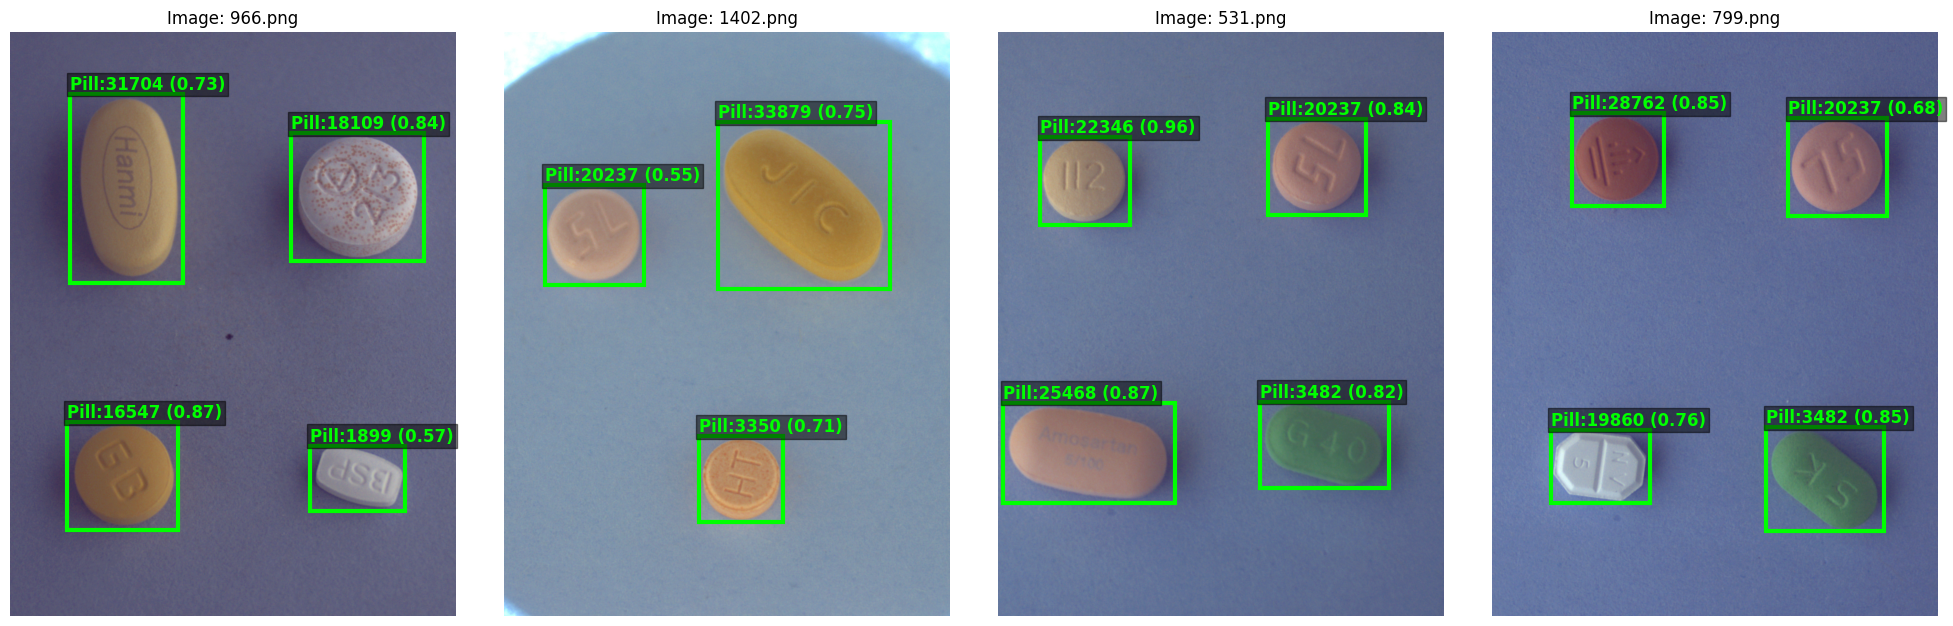

✅ 랜덤하게 선택된 4장의 이미지 시각화 완료!


In [47]:
import matplotlib.pyplot as plt
import cv2
import random

# --- 기존 코드의 2번 단계 바로 뒤에 추가 ---

# [시각화 설정]
NUM_SAMPLES = 4      # 보여줄 랜덤 이미지 개수
CONF_THRES = 0.25    # 박스를 그릴 최소 신뢰도 (predict와 맞춤)

# 1. 랜덤하게 시각화할 이미지 선택
# results 객체는 리스트이므로 인덱스로 접근합니다.
sample_indices = random.sample(range(len(results)), NUM_SAMPLES)

# 2. 시각화 루프 시작
plt.figure(figsize=(20, 10)) # 전체 그림 크기 설정

for i, idx in enumerate(sample_indices):
    r = results[idx]
    
    # 원본 이미지 로드 (BGR -> RGB 변환 필수)
    img = cv2.imread(r.path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 이미지 파일명 추출
    file_name = os.path.basename(r.path)
    
    # 서브플롯 생성
    plt.subplot(1, NUM_SAMPLES, i + 1)
    plt.imshow(img)
    plt.title(f"Image: {file_name}")
    plt.axis('off') # 축 숨기기
    
    # 3. 해당 이미지의 검출된 박스들 그리기
    for box in r.boxes:
        conf = float(box.conf[0])
        
        # 신뢰도 임계값 체크
        if conf < CONF_THRES:
            continue
            
        # 좌표 (xyxy 포맷)
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls_id = int(box.cls[0])
        
        # 원본 카테고리 ID로 변환 (yolo2orig 매핑 사용)
        orig_cat = yolo2orig[cls_id]
        
        # 박스 그리기
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                             fill=False, edgecolor='lime', linewidth=3)
        plt.gca().add_patch(rect)
        
        # 라벨 텍스트 추가 (클래스 ID + 신뢰도)
        label_text = f"Pill:{orig_cat} ({conf:.2f})"
        plt.text(x1, y1 - 10, label_text, color='lime', 
                 fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='black', alpha=0.5, pad=2))

plt.tight_layout()
plt.show()

print(f"✅ 랜덤하게 선택된 {NUM_SAMPLES}장의 이미지 시각화 완료!")

# --- 이후 기존 코드의 3번(데이터프레임 생성) 단계로 이어짐 ---